<a href="https://colab.research.google.com/github/ChiaraTagiullo/Machine_Learning_for_NLP/blob/main/04_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Supervised Classification

In this notebook, we move from unsupervised analysis to supervised learning.

The objective is to predict political support based on textual features extracted from the Archelec corpus.

This task allows us to evaluate whether the lexical information contained in the documents is sufficient to distinguish between political affiliations.

We compare several models:
- Logistic Regression (baseline)
- Support Vector Machine (SVM)

We evaluate performance using accuracy and F1-score.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archelec_LDA_final.xlsx to archelec_LDA_final.xlsx


In [2]:
import pandas as pd

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

print(df.shape)
df.head()

(33029, 44)


,id,date,year,month,contexte-election,contexte-tour,departement,departement-nom,departement-insee,identifiant de circonscription,...,n_words_clean,support_grouped,cluster,topic_0,topic_1,topic_2,topic_3,dominant_topic,dominant_topic_id,topic_name
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,1958,11,législatives,1,1000.0,Ain,01 - Ain,1000.0,...,18,Other,1,74292137,1220838,49272156,4876408,topic_2,2,Institutional and center-right governance
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,1958,11,législatives,1,1000.0,Ain,01 - Ain,1000.0,...,18,Other,1,7430501,6043612,37786314,10345124,topic_1,1,Right-wing and nationalist politics
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,1958,11,législatives,1,1000.0,Ain,01 - Ain,1000.0,...,15,Parti communiste français,4,91776,1509933,22249842,9534732,topic_3,3,Left-wing and socialist/communist politics
3,EL009_L_1958_11_001_01_1_PF_04,1958-11-23,1958,11,législatives,1,1000.0,Ain,01 - Ain,1000.0,...,14,non mentionné,1,9192122,15386017,83699316,1384287,topic_2,2,Institutional and center-right governance
4,EL009_L_1958_11_001_01_1_PF_05,1958-11-23,1958,11,législatives,1,1000.0,Ain,01 - Ain,1000.0,...,22,Other,1,5642067,9385763,9771519,7820282,topic_2,2,Institutional and center-right governance


## 1. Preparing the classification dataset

We use the cleaned text (`text_clean`) as input and political support (`titulaire-soutien`) as target.

To ensure a meaningful classification task, we restrict the dataset to the most frequent political supports.

In [3]:
# rimuovi NaN
df = df[df["titulaire-soutien"].notna()].copy()

# top 8 classi
top_supports = df["titulaire-soutien"].value_counts().head(8).index

df_clf = df[df["titulaire-soutien"].isin(top_supports)].copy()

df_clf["titulaire-soutien"].value_counts()

,count
titulaire-soutien,
non mentionné,6221
Parti communiste français,4602
Parti socialiste,1823
Front national,1386
Lutte ouvrière,1076
Parti socialiste unifié,930
Rassemblement pour la République;Union pour la démocratie française,807
Rassemblement pour la République,660


In [4]:
from sklearn.model_selection import train_test_split

X = df_clf["text_clean"]
y = df_clf["titulaire-soutien"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 14004
Test size: 3501


## 2. Text vectorization

We transform text into numerical features using TF-IDF.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_df=0.95,
    min_df=5,
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape)

(14004, 1787)


## 3. Logistic Regression (baseline model)

In [6]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [7]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = lr.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9865752642102257
                                                                     precision    recall  f1-score   support

                                                     Front national       0.99      1.00      0.99       277
                                                     Lutte ouvrière       1.00      1.00      1.00       215
                                          Parti communiste français       1.00      1.00      1.00       920
                                                   Parti socialiste       1.00      0.98      0.99       365
                                            Parti socialiste unifié       1.00      0.99      0.99       186
                                   Rassemblement pour la République       0.95      0.80      0.87       132
Rassemblement pour la République;Union pour la démocratie française       0.96      0.99      0.98       162
                                                      non mentionné       0.98      0.99      0.98

### Interpretation — Logistic Regression

The Logistic Regression model achieves an accuracy of approximately 0.987, indicating that textual features provide strong signals for predicting political support.

Performance is very high across most classes, with precision and recall close to 1.00 for major political parties such as the Communist Party and Lutte ouvrière. This suggests that these groups have highly distinctive lexical profiles.

However, performance is slightly lower for "Rassemblement pour la République", where recall drops to 0.80. This indicates that some documents from this class are misclassified, likely due to lexical overlap with other right-wing or institutional political groups.

Overall, Logistic Regression provides a strong baseline and confirms that political affiliation is highly predictable from textual data.

## 4. Support Vector Machine

In [8]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train_tfidf, y_train)

LinearSVC()

In [9]:
y_pred_svm = svm.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.992002285061411
                                                                     precision    recall  f1-score   support

                                                     Front national       0.99      1.00      1.00       277
                                                     Lutte ouvrière       1.00      1.00      1.00       215
                                          Parti communiste français       1.00      1.00      1.00       920
                                                   Parti socialiste       1.00      0.99      1.00       365
                                            Parti socialiste unifié       1.00      0.99      1.00       186
                                   Rassemblement pour la République       0.98      0.86      0.92       132
Rassemblement pour la République;Union pour la démocratie française       0.95      1.00      0.98       162
                                                      non mentionné       0.99      0.99      0.99 

### Interpretation — Support Vector Machine

The Support Vector Machine achieves an accuracy of approximately 0.992, slightly outperforming Logistic Regression.

Performance is extremely high across all classes, with most precision and recall scores close to 1.00. This confirms that the TF-IDF representation effectively captures discriminative lexical features.

The only class with slightly lower performance is "Rassemblement pour la République", with recall around 0.86. This suggests that this political group shares vocabulary with other center-right or institutional actors, making it more difficult to distinguish.

The improvement over Logistic Regression indicates that SVM is better suited to handling high-dimensional sparse text data, providing more precise decision boundaries between classes.

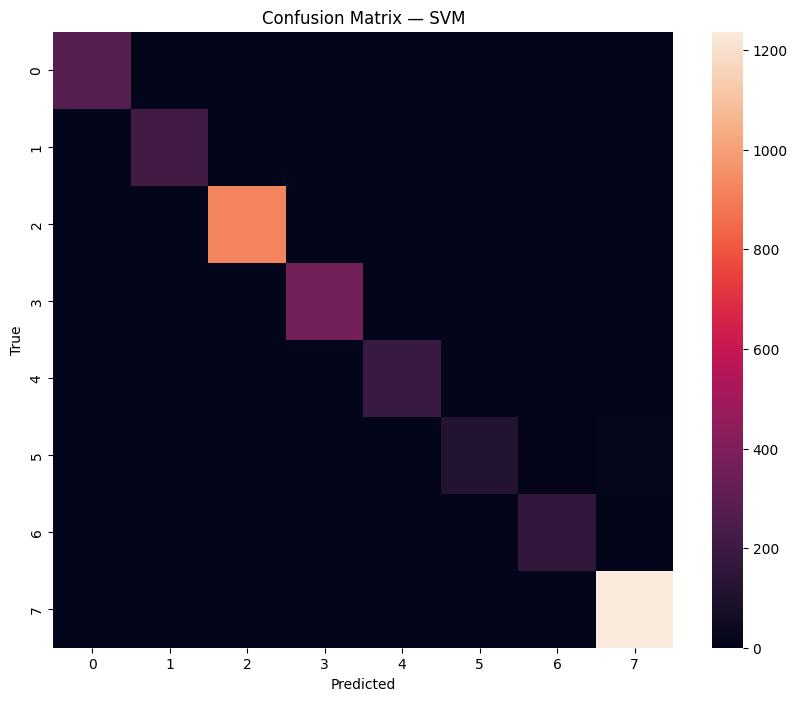

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix — SVM")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### Interpretation — Confusion matrix

The confusion matrix shows that most predictions fall along the diagonal, indicating very high classification accuracy.

Misclassifications are rare and mainly occur between ideologically or lexically similar classes. In particular, some confusion appears for "Rassemblement pour la République", which is occasionally misclassified as closely related center-right political groups.

The near-perfect separation for classes such as "Parti communiste français" and "Lutte ouvrière" confirms that these political identities have highly distinctive lexical signatures.

Overall, the confusion matrix demonstrates that the classification task is relatively easy given the strong lexical cues present in the dataset.

## 5. Most important features

In [11]:
feature_names = vectorizer.get_feature_names_out()

for i, class_label in enumerate(lr.classes_):
    top_indices = lr.coef_[i].argsort()[-10:]
    print(f"\nClass: {class_label}")
    print(", ".join(feature_names[top_indices]))


Class: Front national
marine, regional, patrie, idees, europeennes, votez, liste, entente, front, national

Class: Lutte ouvrière
faire, ouvrier, camp, travailleurs, arlette, europeennes, employee, laguiller, ouvriere, lutte

Class: Parti communiste français
paix, democratiques, commun, programme, changement, gauche, forces, parti, francais, communiste

Class: Parti socialiste
democrates, tous, changer, president, gauche, alliance, progres, vie, parti, socialiste

Class: Parti socialiste unifié
alternative, pouvoir, actuelle, finir, socialisme, autogestionnaire, syndicat, parti, socialiste, unifie

Class: Rassemblement pour la République
jacques, nouvelle, renouveau, opposition, claude, paysans, sociaux, independants, majorite, rassemblement

Class: Rassemblement pour la République;Union pour la démocratie française
chambre, adjoint, dehaine, professionnel, local, opposition, rassemblement, union, democratie, francaise

Class: non mentionné
proletarienne, oui, republicain, forces, uni

### Interpretation — Feature importance

The most important features for each class correspond to highly meaningful political terms and names.

For example, the "Front national" class is strongly associated with terms such as "front", "national", and references to elections and political lists. The "Lutte ouvrière" class includes distinctive terms such as "ouvrier", "travailleurs", and references to known political figures such as "Arlette Laguiller".

The "Parti communiste français" is characterized by terms such as "communiste", "français", "forces", and "programme", reflecting its ideological discourse. Similarly, the "Parti socialiste" includes terms such as "socialiste", "progrès", and "gauche".

The "Parti socialiste unifié" is associated with more specific ideological terms such as "autogestionnaire" and "socialisme", indicating a more specialized vocabulary.

For right-wing and center-right groups such as "Rassemblement pour la République", features include "majorité", "renouveau", and references to political figures, reflecting a more institutional and leadership-oriented discourse.

Overall, the feature importance analysis confirms that the model relies on meaningful political vocabulary, and that each class is characterized by a distinct lexical profile.

In [12]:
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_lr))
print("SVM accuracy:", accuracy_score(y_test, y_pred_svm))

Logistic Regression accuracy: 0.9865752642102257
SVM accuracy: 0.992002285061411


### Interpretation — Model comparison

Both models achieve very high performance, with accuracy above 0.98.

The SVM slightly outperforms Logistic Regression, achieving an accuracy of approximately 0.992 compared to 0.987. This confirms that margin-based models are particularly effective for high-dimensional text classification tasks.

However, the difference between the two models is relatively small, indicating that the classification task is inherently well-structured due to the strong lexical signals present in the data.

Overall, both models demonstrate that political support can be predicted with very high accuracy using simple NLP techniques.

## Final conclusions

This project explored the Archelec corpus using a range of Natural Language Processing techniques, combining exploratory analysis, statistical modeling, unsupervised learning, and supervised classification.

The initial exploratory analysis revealed that the dataset is highly structured and contains strong imbalances across time, geography, and political representation. The textual content is relatively short and largely composed of institutional and biographical descriptors.

Statistical NLP methods, including Bag-of-Words and TF-IDF, showed that the vocabulary is dominated by political affiliations, institutional roles, and candidate profiles. Despite the structured nature of the text, the corpus exhibits standard linguistic properties such as Zipf’s law.

Unsupervised methods provided deeper insights into the latent structure of the data. Topic modeling using LDA identified four coherent political profiles corresponding to ecological movements, right-wing and nationalist politics, institutional center-right governance, and left-wing political traditions. These topics were validated through coherence scores, metadata analysis, and qualitative inspection of representative documents.

Clustering analysis confirmed the presence of similar structures, showing that different unsupervised approaches capture consistent patterns in the corpus.

Finally, supervised classification demonstrated that political support can be predicted with very high accuracy using textual features alone. Both Logistic Regression and Support Vector Machines achieved near-perfect performance, confirming that the lexical signals in the data are highly discriminative.

Overall, the project shows that the Archelec corpus, despite its limitations, contains rich and interpretable political structures. The combination of unsupervised and supervised NLP methods provides a comprehensive understanding of the data, highlighting both its strengths and its constraints.

These results demonstrate the effectiveness of classical NLP techniques in analyzing structured political text and extracting meaningful insights from historical electoral data.